In [1]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import rebound as rb
import plotly.graph_objects as go

Bienvenido a PyMCel v0.9.17 ¡al infinito y más allá!


In [2]:
rb.horizons.SSL_CONTEXT = 'unverified'

In [3]:
sim_solar = rb.Simulation()
sim_solar.add('Sun',date='2026-01-01')
sim_solar.add('Earth',date='2026-01-01')
sim_solar.add('Apophis',date='2026-01-01')
sim_solar.add('Jupiter',date='2026-01-01')

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 
Searching NASA Horizons for 'Jupiter'... 


c:\Users\jaide\OneDrive\Documentos\Visual_Projects\MecCel-20261-Project\MecCel-20261-Project\meccelenv312project\Lib\site-packages\rebound\horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')


In [4]:
sim_solar.status()

---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 11 2026 17:44:35
Number of particles: 	4
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x1f0d98976d0, m=0.9999999999950272 x=-0.003067316167378725 y=-0.005533329071575706 z=0.00013168419397952 vx=0.00041716254822091994 vy=1.0336727677051391e-05 vz=-7.899371019067428e-06>
<rebound.particle.Particle object at 0x1f0d98e0550, m=3.0404326489511185e-06 x=-0.17733707471568377 y=0.9622523452526153 z=7.48181126171124e-05 vx=-1.000134877239406 vy=-0.18099394589373236 vz=8.166853042470314e-06>
<rebound.particle.Particle object at 0x1f0d98976d0, m=0.0 x=0.6306953539299172 y=-0.3977098912292628 z=0.0360513270014221 vx=0.6594530762068974 vy=1.0771195165053096 vz=-0.041908818147308985>
<rebound.particle.Particle object at 0x1f0d98e0550, m=0.0009547919099366768 x=-1.6970703463532244 y=4.9

In [4]:
ts = np.linspace(0, 100, 1000)
rs = np.zeros((4, 1000, 3))
vs = np.zeros((4, 1000, 3))
rps = np.zeros((4, 1000, 3))
vps = np.zeros((4, 1000, 3))

for i,t in enumerate(ts):
    sim_solar.integrate(t)
    rs[0,i] = sim_solar.particles[0].xyz
    vs[0,i] = sim_solar.particles[0].vxyz
    rs[1,i] = sim_solar.particles[1].xyz
    vs[1,i] = sim_solar.particles[1].vxyz
    rs[2,i] = sim_solar.particles[2].xyz
    vs[2,i] = sim_solar.particles[2].vxyz
    rs[3,i] = sim_solar.particles[3].xyz
    vs[3,i] = sim_solar.particles[3].vxyz
    sim_solar.move_to_com()
    rps[0,i] = sim_solar.particles[0].xyz
    vps[0,i] = sim_solar.particles[0].vxyz
    rps[1,i] = sim_solar.particles[1].xyz
    vps[1,i] = sim_solar.particles[1].vxyz
    rps[2,i] = sim_solar.particles[2].xyz
    vps[2,i] = sim_solar.particles[2].vxyz
    rps[3,i] = sim_solar.particles[3].xyz
    vps[3,i] = sim_solar.particles[3].vxyz

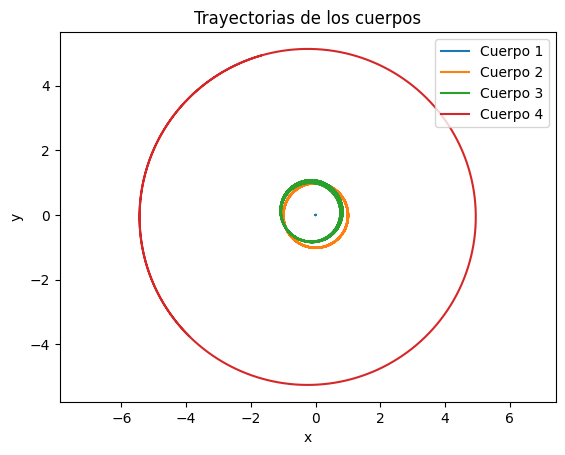

In [6]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Cuerpo 1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Cuerpo 2')
plt.plot(rps[2,:,0], rps[2,:,1], label='Cuerpo 3')
plt.plot(rps[3,:,0], rps[3,:,1], label='Cuerpo 4')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.axis('equal')
plt.show()

Momento lineal total

In [7]:
suma = 0
for i in range(4):
    suma += sim_solar.particles[i].m*vps[i,0,:]
print(suma)

[0.00000000e+00 1.35525272e-20 1.69406589e-21]


In [8]:
suma_t = 0
for i in range(4):
    suma_t += sim_solar.particles[i].m*vps[i,999,:]
print(suma_t)

[0. 0. 0.]


Momento angular total

In [9]:
suma = 0
for i in range(4):
    suma += sim_solar.particles[i].m * np.cross(rps[i,0,:], vps[i,0,:])
print(suma)

[4.86309475e-05 9.02919851e-06 2.17665750e-03]


In [10]:
sumat_t = 0
for i in range(2):
  sumat_t += sim_solar.particles[i].m * np.cross(rps[i,999,:], vps[i,999,:])
print(sumat_t)

[4.63997781e-08 8.83345584e-09 5.11336276e-06]


Energías cinetica y potencial

In [11]:
K = 0
for i in range(4):
    K += 0.5 * sim_solar.particles[i].m * (vps[i,0,0]**2 + vps[i,0,1]**2 + vps  [i,0,2]**2)**0.5
print(K)

0.0004207253263672312


In [12]:
G = 1
U = 0
for i in range(4):
    for j in range(4):
        if i != j:
            U += -G * sim_solar.particles[i].m * sim_solar.particles[j].m / ((rps[i,0,0] - rps[j,0,0])**2 + (rps[i,0,1] - rps[j,0,1])**2 + (rps[i,0,2] - rps[j,0,2])**2)**0.5
U = U/2
print(U)

-0.00018628741477887147


In [5]:
def anima_ncuerpos(masas, rps, T):
    N = rps.shape[0]
    Nt = rps.shape[1]
    T_total = Nt * (T / Nt)  # tiempo total de la simulación
    
    # Colores de las partículas
    colors_hex = [f'hsl({int(j/N*360)},70%,50%)' for j in range(N)]

    # Submuestreo para que la animación sea fluida pero no pesada
    n_frames = 120
    idx = np.linspace(0, Nt - 1, n_frames, dtype=int)
    s_markers = [min(30, max(4, int(masas[j] * 120 + 4))) for j in range(N)]

    base_traces = []
    for j in range(N):
        base_traces.append(go.Scatter3d(
            x=rps[j, :, 0], y=rps[j, :, 1], z=rps[j, :, 2],
            mode='lines',
            line=dict(color=colors_hex[j], width=1),
            opacity=0.25,
            showlegend=False,
            hoverinfo='skip'
        ))

    # Posiciones iniciales de los cuerpos (frame 0)
    for j in range(N):
        base_traces.append(go.Scatter3d(
            x=[rps[j, idx[0], 0]],
            y=[rps[j, idx[0], 1]],
            z=[rps[j, idx[0], 2]],
            mode='markers',
            marker=dict(color=colors_hex[j], size=s_markers[j],
                        line=dict(color='black', width=0.5)),
            name=f'Cuerpo {j+1}',
            showlegend=False
        ))

    frames = []
    for fi, ki in enumerate(idx):
        frame_data = []
        # Las N primeras trazas son trayectorias (no cambian); actualizamos sólo las N de puntos
        for j in range(N):
            frame_data.append(go.Scatter3d(
                x=[rps[j, ki, 0]],
                y=[rps[j, ki, 1]],
                z=[rps[j, ki, 2]],
            ))
        frames.append(go.Frame(
            data=frame_data,
            traces=list(range(N, 2 * N)),   # índices de las trazas de puntos
            name=str(fi)
        ))

    fig_anim = go.Figure(data=base_traces, frames=frames)
    fig_anim.update_layout(
        title=dict(
            text=f'Animación 3D — {N} cuerpos — T = {T_total} u.t.c.',
            x=0.5
        ),
        scene=dict(
            xaxis_title='x [u.c.]',
            yaxis_title='y [u.c.]',
            zaxis_title='z [u.c.]',
            aspectmode='data'
        ),
        width=860, height=760,
        margin=dict(l=0, r=0, b=0, t=50),
        updatemenus=[dict(
            type='buttons',
            showactive=False,
            y=0.02, x=0.5, xanchor='center',
            buttons=[
                dict(label='▶ Play',
                    method='animate',
                    args=[None, dict(frame=dict(duration=40, redraw=True),
                                    fromcurrent=True, mode='immediate')]),
                dict(label='⏸ Pausa',
                    method='animate',
                    args=[[None], dict(frame=dict(duration=0, redraw=False),
                                        mode='immediate')])
            ]
        )],
        sliders=[dict(
            currentvalue=dict(prefix='Frame: ', visible=True, xanchor='center'),
            pad=dict(t=40),
            steps=[dict(method='animate',
                        args=[[str(fi)], dict(mode='immediate',
                                            frame=dict(duration=0, redraw=True))],
                        label=str(fi))
                for fi in range(n_frames)]
        )]
    )
    fig_anim.show()

In [6]:
masas = [sim_solar.particles[i].m for i in range(4)]
anima_ncuerpos(masas, rps, T=100)